# Grammar Scoring Engine for Spoken Audio

**Goal:** predict a continuous MOS-Likert grammar score (0-5) from a 45-60 s speech clip.

**Approach in one paragraph.** Grammar is a property of *what was said*, so we first convert speech to text with
Whisper (ASR), then describe each clip with three complementary feature families:
(1) **text/grammar features** (GPT-2 fluency/perplexity, LanguageTool error rates, sentence statistics, fillers, repetitions),
(2) **semantic sentence embeddings** of the transcript, and (3) **acoustic/prosodic features** (pause statistics, speech rate, ASR confidence, wav2vec2 embeddings).
Several regressors are trained with K-fold cross-validation, ensembled, and evaluated with **RMSE** and **Pearson correlation**.
The final report (metrics, plots, discussion) is at the bottom of the notebook.

## 1. Setup

In [2]:
# Run once (Colab / Kaggle). Java is needed for LanguageTool:  !apt-get install -y default-jre
!pip install -q faster-whisper librosa soundfile sentence-transformers transformers torch \
             language-tool-python scikit-learn scipy pandas matplotlib seaborn tqdm


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!winget install -e --id EclipseAdoptium.Temurin.17.JRE --accept-source-agreements --accept-package-agreements #java installation

Found Eclipse Temurin JRE with Hotspot 17 [EclipseAdoptium.Temurin.17.JRE] Version 17.0.20.101
This application is licensed to you by its owner.
Microsoft is not responsible for, nor does it grant any licenses to, third-party packages.
Successfully verified installer hash
Starting package install...


In [49]:
!pip install hf_xet

  Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl.metadata (4.9 kB)
Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl (4.0 MB)



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
  !java -version

openjdk version "17.0.20.1" 2026-08-18
OpenJDK Runtime Environment Temurin-17.0.20.1+1 (build 17.0.20.1+1)
OpenJDK 64-Bit Server VM Temurin-17.0.20.1+1 (build 17.0.20.1+1, mixed mode, sharing)


In [2]:
import os, re, warnings, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import librosa
import torch

from scipy.stats import pearsonr
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

C:\Users\John Paul Hilson\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
# ----------------------------- CONFIG: edit these paths -----------------------------
DATA_DIR   = Path("Downloads/shl-hiring-assessment-2026/Dataset_Final/")             # folder containing train.csv, test.csv, sample_submission.csv and the audio
TRAIN_CSV  = DATA_DIR / "train.csv"
TEST_CSV   = DATA_DIR / "test.csv"
SAMPLE_SUB = DATA_DIR / "sample_submission.csv"
CACHE_DIR  = Path("./cache"); CACHE_DIR.mkdir(exist_ok=True)   # transcripts / features are cached here
SR = 16000                              # sample rate expected by Whisper and wav2vec2
USE_LANGUAGETOOL = True                 # set False if Java is unavailable (falls back gracefully)

In [4]:
# ----------------------------- CONFIG: edit these paths -----------------------------
from pathlib import Path

DATA_DIR   = Path.home() / "Downloads" / "shl-hiring-assessment-2026" / "Dataset_Final"   # folder with the CSVs and audio
assert DATA_DIR.exists(), f"Folder not found: {DATA_DIR}"

def find_file(name):
    # looks in DATA_DIR first, then in any sub-folder
    direct = DATA_DIR / name
    if direct.exists():
        return direct
    hits = list(DATA_DIR.rglob(name))
    assert hits, f"{name} not found under {DATA_DIR}"
    return hits[0]

TRAIN_CSV  = find_file("train.csv")
TEST_CSV   = find_file("test.csv")
SAMPLE_SUB = find_file("sample_submission.csv")
CACHE_DIR  = Path("./cache"); CACHE_DIR.mkdir(exist_ok=True)   # transcripts / features are cached here
SR = 16000                              # sample rate expected by Whisper and wav2vec2
USE_LANGUAGETOOL = True                 # set False if Java is unavailable (falls back gracefully)

print("Data folder:", DATA_DIR)
print("train:", TRAIN_CSV.name, "| test:", TEST_CSV.name, "| sample:", SAMPLE_SUB.name)
print("WAV files found:", len(list(DATA_DIR.rglob("*.wav"))))

Data folder: C:\Users\John Paul Hilson\Downloads\shl-hiring-assessment-2026\Dataset_Final
train: train.csv | test: test.csv | sample: sample_submission.csv
WAV files found: 985


## 2. Load data & exploratory analysis

In [5]:
train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)
sub   = pd.read_csv(SAMPLE_SUB)

# Auto-detect column names (file-name column = first column, label = the numeric column that is not the file name)
FILE_COL  = train.columns[0]
LABEL_COL = [c for c in train.columns if c != FILE_COL and pd.api.types.is_numeric_dtype(train[c])][0]
print("File column:", FILE_COL, "| Label column:", LABEL_COL)
print(train.shape, test.shape, sub.shape)

# Map file names -> full paths (searches sub-folders, so the folder layout does not matter)
wav_index = {p.name: p for p in DATA_DIR.rglob("*.wav")}
wav_index.update({p.stem: p for p in DATA_DIR.rglob("*.wav")})
def resolve(name):
    name = str(name)
    return wav_index.get(name) or wav_index.get(name + ".wav") or wav_index.get(Path(name).stem)

train["path"] = train[FILE_COL].map(resolve)
test["path"]  = test[FILE_COL].map(resolve)
assert train["path"].notna().all() and test["path"].notna().all(), "Some audio files were not found - check DATA_DIR"
train.head()

File column: filename | Label column: label
(769, 2) (216, 2) (204, 2)


,filename,label,path
0,audio_192.wav,3.0,C:\Users\John Paul Hilson\Downloads\shl-hiring...
1,audio_436.wav,3.0,C:\Users\John Paul Hilson\Downloads\shl-hiring...
2,audio_447.wav,3.5,C:\Users\John Paul Hilson\Downloads\shl-hiring...
3,audio_126.wav,2.0,C:\Users\John Paul Hilson\Downloads\shl-hiring...
4,audio_61.wav,2.0,C:\Users\John Paul Hilson\Downloads\shl-hiring...


durations: 100%|██████████| 769/769 [00:05<00:00, 148.94it/s]


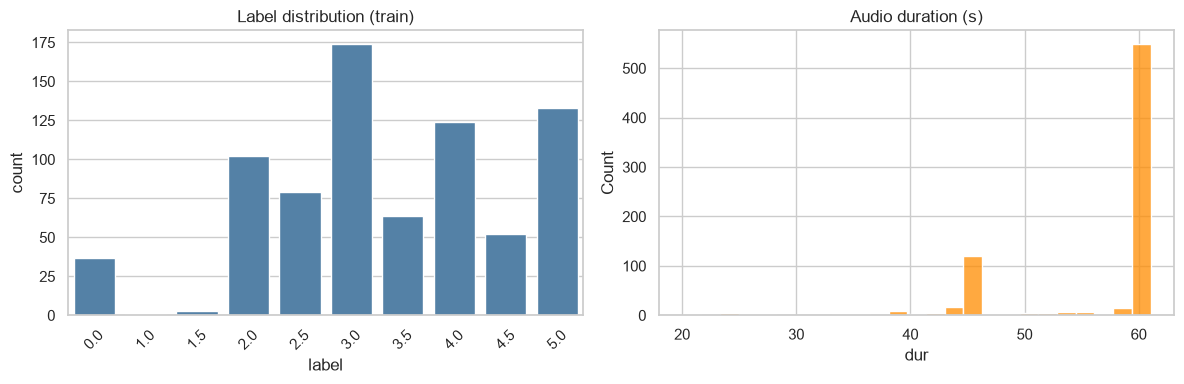

count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=train[LABEL_COL].round(1), ax=ax[0], color="steelblue")
ax[0].set_title("Label distribution (train)"); ax[0].tick_params(axis="x", rotation=45)
train["dur"] = [librosa.get_duration(path=str(p)) for p in tqdm(train["path"], desc="durations")]
sns.histplot(train["dur"], bins=25, ax=ax[1], color="darkorange")
ax[1].set_title("Audio duration (s)")
plt.tight_layout(); plt.show()
print(train[LABEL_COL].describe())

## 3. Speech-to-text (Whisper)
We use `faster-whisper` with word-level timestamps. Besides the transcript we keep timing and confidence information,
which feed the prosodic/fluency features. Results are cached to disk so the (slow) step runs only once.

In [11]:
from faster_whisper import WhisperModel

asr = WhisperModel("small.en", device=DEVICE, compute_type="float16" if DEVICE == "cuda" else "int8")

def transcribe(path):
    segments, info = asr.transcribe(str(path), language="en", word_timestamps=True,
                                    beam_size=5, vad_filter=False, condition_on_previous_text=False)
    segments = list(segments)
    words = [(w.word.strip(), w.start, w.end, w.probability) for s in segments for w in (s.words or [])]
    return {
        "text": " ".join(s.text.strip() for s in segments).strip(),
        "words": words,
        "avg_logprob": float(np.mean([s.avg_logprob for s in segments])) if segments else -5.0,
        "no_speech": float(np.mean([s.no_speech_prob for s in segments])) if segments else 1.0,
        "duration": info.duration,
    }

def run_asr(df, name):
    cache = CACHE_DIR / f"asr_{name}.json"
    if cache.exists():
        return json.load(open(cache))
    out = [transcribe(p) for p in tqdm(df["path"], desc=f"ASR {name}")]
    json.dump(out, open(cache, "w"))
    return out

asr_train = run_asr(train, "train")
asr_test  = run_asr(test, "test")
print(train[FILE_COL].iloc[0], "->", asr_train[0]["text"][:300])

ASR train:   1%|          | 5/769 [03:04<7:50:12, 36.93s/it]

audio_192.wav -> Well, the playground is very, very beautiful and fun. There are, there are playthings like the merry-go-round, the swing, the students usually enjoy the swing. It has to be like, it's more like a gimbal space, because one system is, and the other system will have to push, and the mirror goes around,


## 4. Feature engineering
### 4.1 Hand-crafted text, fluency and prosody features

In [12]:
FILLERS = {"um", "uh", "er", "erm", "ah", "hmm", "mm"}
FILLER_PHRASES = ["you know", "i mean", "kind of", "sort of"]

def handcrafted(a):
    text, words = a["text"], a["words"]
    toks = [re.sub(r"[^a-z']", "", w[0].lower()) for w in words]
    toks = [t for t in toks if t]
    n = max(len(toks), 1)
    dur = max(a["duration"], 1e-6)
    sents = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    sent_len = [len(s.split()) for s in sents] or [0]

    # pauses between consecutive words
    gaps = np.array([words[i + 1][1] - words[i][2] for i in range(len(words) - 1)]) if len(words) > 1 else np.array([0.0])
    gaps = np.clip(gaps, 0, None)
    speech_time = max(sum(w[2] - w[1] for w in words), 1e-6)
    probs = np.array([w[3] for w in words]) if words else np.array([0.0])

    return {
        "n_words": len(toks),
        "n_unique": len(set(toks)),
        "ttr": len(set(toks)) / n,
        "n_sents": len(sents),
        "avg_sent_len": float(np.mean(sent_len)),
        "std_sent_len": float(np.std(sent_len)),
        "max_sent_len": float(np.max(sent_len)),
        "avg_word_len": float(np.mean([len(t) for t in toks])) if toks else 0,
        "long_word_ratio": float(np.mean([len(t) > 6 for t in toks])) if toks else 0,
        "filler_rate": sum(t in FILLERS for t in toks) / n,
        "filler_phrase_rate": sum(text.lower().count(p) for p in FILLER_PHRASES) / n,
        "repeat_rate": sum(toks[i] == toks[i - 1] for i in range(1, len(toks))) / n,       # "I I want"
        "comma_rate": text.count(",") / n,
        "speech_rate_wps": len(toks) / dur,
        "articulation_rate": len(toks) / speech_time,
        "pause_mean": float(gaps.mean()), "pause_max": float(gaps.max()),
        "pause_gt_0.5": int((gaps > 0.5).sum()), "pause_gt_1.0": int((gaps > 1.0).sum()),
        "speech_ratio": speech_time / dur,
        "asr_word_prob_mean": float(probs.mean()), "asr_word_prob_min": float(probs.min()),
        "asr_low_conf_ratio": float((probs < 0.5).mean()),
        "asr_avg_logprob": a["avg_logprob"], "asr_no_speech": a["no_speech"],
    }

H_train = pd.DataFrame([handcrafted(a) for a in asr_train])
H_test  = pd.DataFrame([handcrafted(a) for a in asr_test])
H_train.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
n_words,769.0,99.685306,26.994932,0.0,81.000000,101.000000,121.000000,152.000000
n_unique,769.0,59.475943,14.987052,0.0,49.000000,59.000000,70.000000,107.000000
ttr,769.0,0.607880,0.092963,0.0,0.546296,0.603960,0.661972,1.000000
n_sents,769.0,4.690507,2.558264,0.0,3.000000,4.000000,6.000000,15.000000
avg_sent_len,769.0,29.636110,23.809644,0.0,16.111111,21.000000,32.333333,144.000000
std_sent_len,769.0,11.254940,8.935514,0.0,5.356071,8.782875,15.099669,51.500000
max_sent_len,769.0,46.728218,24.937009,0.0,28.000000,39.000000,59.000000,144.000000
avg_word_len,769.0,4.207673,0.429794,0.0,3.924812,4.180000,4.431193,5.767123
long_word_ratio,769.0,0.162456,0.062704,0.0,0.120000,0.154545,0.196262,0.432000
filler_rate,769.0,0.000715,0.005496,0.0,0.000000,0.000000,0.000000,0.069767


### 4.2 Language-model fluency (GPT-2 perplexity) and grammar errors (LanguageTool)

In [13]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

lm_tok = GPT2TokenizerFast.from_pretrained("gpt2")
lm = GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE).eval()

@torch.no_grad()
def lm_features(text):
    ids = lm_tok(text, return_tensors="pt", truncation=True, max_length=512).input_ids.to(DEVICE)
    if ids.shape[1] < 2:
        return {"lm_nll_mean": 6.0, "lm_nll_std": 0.0, "lm_nll_p90": 6.0}
    logits = lm(ids).logits[:, :-1]
    nll = torch.nn.functional.cross_entropy(logits[0], ids[0, 1:], reduction="none").cpu().numpy()
    return {"lm_nll_mean": nll.mean(), "lm_nll_std": nll.std(), "lm_nll_p90": np.percentile(nll, 90)}

LM_train = pd.DataFrame([lm_features(a["text"]) for a in tqdm(asr_train, desc="GPT-2 train")])
LM_test  = pd.DataFrame([lm_features(a["text"]) for a in tqdm(asr_test, desc="GPT-2 test")])

GPT-2 test: 100%|██████████| 216/216 [01:07<00:00,  3.20it/s]


In [14]:
# LanguageTool: counts rule-based grammar / spelling / style issues. Needs Java + internet for the first download.
def build_lt():
    if not USE_LANGUAGETOOL:
        return None
    try:
        import language_tool_python
        return language_tool_python.LanguageTool("en-US")
    except Exception as e:
        print("LanguageTool unavailable -> skipping:", e)
        return None

lt = build_lt()
LT_COLS = ["lt_err_total", "lt_err_per_100w", "lt_grammar", "lt_typos", "lt_style", "lt_punct"]

def lt_features(text):
    if lt is None:
        return dict.fromkeys(LT_COLS, 0.0)
    matches = lt.check(text)
    n = max(len(text.split()), 1)
    cat = lambda *keys: sum(any(k in (m.category or "").upper() for k in keys) for m in matches)
    return {"lt_err_total": len(matches), "lt_err_per_100w": 100 * len(matches) / n,
            "lt_grammar": cat("GRAMMAR"), "lt_typos": cat("TYPO"), "lt_style": cat("STYLE"), "lt_punct": cat("PUNCT")}

cache_lt = CACHE_DIR / "lt.pkl"
if cache_lt.exists():
    LT_train, LT_test = pd.read_pickle(cache_lt)
else:
    LT_train = pd.DataFrame([lt_features(a["text"]) for a in tqdm(asr_train, desc="LT train")])
    LT_test  = pd.DataFrame([lt_features(a["text"]) for a in tqdm(asr_test, desc="LT test")])
    pd.to_pickle((LT_train, LT_test), cache_lt)

LT test: 100%|██████████| 216/216 [00:13<00:00, 15.69it/s]


In [27]:
%pip install -q tf-keras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 4.3 Embeddings: transcript (sentence-transformer) and raw audio (wav2vec2)

In [15]:
from sentence_transformers import SentenceTransformer
st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=DEVICE)
ST_train = st_model.encode([a["text"] for a in asr_train], batch_size=32, show_progress_bar=True)
ST_test  = st_model.encode([a["text"] for a in asr_test],  batch_size=32, show_progress_bar=True)
print(ST_train.shape)

Batches: 100%|██████████| 7/7 [00:07<00:00,  1.05s/it]

(769, 384)


In [16]:
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

w2v_fe = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
w2v = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(DEVICE).eval()

@torch.no_grad()
def w2v_embed(path):
    y, _ = librosa.load(str(path), sr=SR, mono=True, duration=60)
    inp = w2v_fe(y, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE)
    h = w2v(inp, output_hidden_states=True).hidden_states
    # mean/std pooling of one middle layer and the last layer (middle layers carry more linguistic info)
    feats = [h[6][0].mean(0), h[6][0].std(0), h[-1][0].mean(0)]
    return torch.cat(feats).cpu().numpy()

def run_w2v(df, name):
    cache = CACHE_DIR / f"w2v_{name}.npy"
    if cache.exists():
        return np.load(cache)
    arr = np.stack([w2v_embed(p) for p in tqdm(df["path"], desc=f"wav2vec2 {name}")])
    np.save(cache, arr); return arr

W_train, W_test = run_w2v(train, "train"), run_w2v(test, "test")
print(W_train.shape)

(769, 2304)


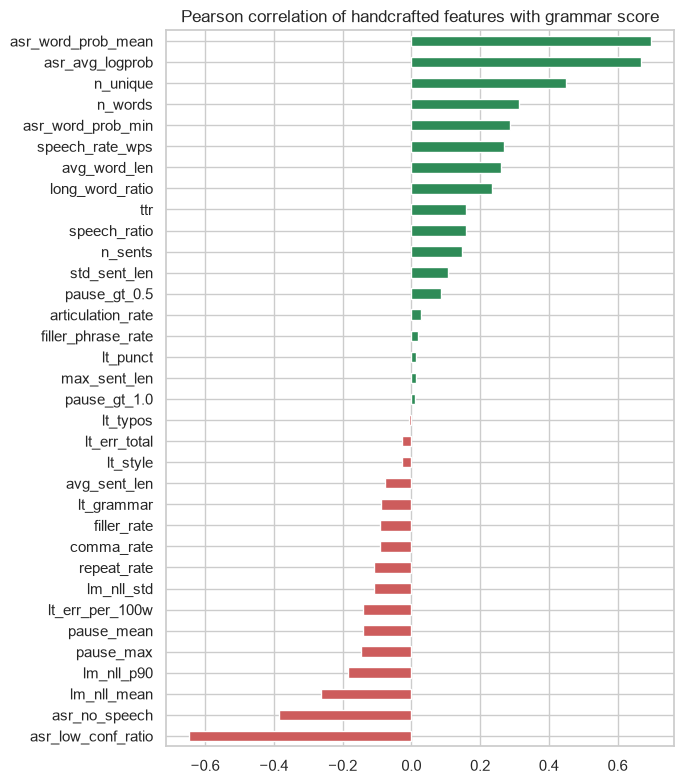

In [17]:
# Assemble feature blocks
HAND_train = pd.concat([H_train, LM_train, LT_train], axis=1).fillna(0)
HAND_test  = pd.concat([H_test,  LM_test,  LT_test],  axis=1).fillna(0)

y = train[LABEL_COL].values.astype(float)
X_blocks_train = {"hand": HAND_train.values, "st": ST_train, "w2v": W_train}
X_blocks_test  = {"hand": HAND_test.values,  "st": ST_test,  "w2v": W_test}

# Correlation of interpretable features with the target
corr = HAND_train.assign(target=y).corr()["target"].drop("target").sort_values()
plt.figure(figsize=(7, 8)); corr.plot.barh(color=np.where(corr > 0, "seagreen", "indianred"))
plt.title("Pearson correlation of handcrafted features with grammar score"); plt.tight_layout(); plt.show()

## 5. Modelling
Four diverse regressors, each on the feature view where it works best, trained with 5-fold CV (out-of-fold, OOF, predictions
give an honest estimate of test performance). The final prediction is the average of the models, clipped to [0, 5].

In [18]:
def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
def evaluate(y_true, y_pred):
    return {"RMSE": rmse(y_true, y_pred), "Pearson": float(pearsonr(y_true, y_pred)[0])}

def stack_blocks(blocks, names): return np.hstack([blocks[n] for n in names])

MODELS = {   # name: (feature blocks, estimator factory)
    "Ridge(hand+st)":    (["hand", "st"],         lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 4, 30)))),
    "Ridge(w2v)":        (["w2v"],                lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(1, 5, 30)))),
    "SVR(hand+st)":      (["hand", "st"],         lambda: make_pipeline(StandardScaler(), SVR(C=2.0, epsilon=0.1, gamma="scale"))),
    "HistGB(hand)":      (["hand"],               lambda: HistGradientBoostingRegressor(max_depth=3, learning_rate=0.04, max_iter=300,
                                                                                        l2_regularization=1.0, random_state=SEED)),
}

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof = {m: np.zeros(len(y)) for m in MODELS}

for m, (names, make) in MODELS.items():
    X = stack_blocks(X_blocks_train, names)
    for tr, va in kf.split(X):
        est = make().fit(X[tr], y[tr])
        oof[m][va] = est.predict(X[va])
    print(f"{m:16s}", {k: round(v, 4) for k, v in evaluate(y, np.clip(oof[m], 0, 5)).items()})

oof["Ensemble (mean)"] = np.mean([oof[m] for m in MODELS], axis=0)
cv_results = pd.DataFrame({m: evaluate(y, np.clip(p, 0, 5)) for m, p in oof.items()}).T.sort_values("RMSE")
cv_results

Ridge(hand+st)   {'RMSE': 0.7638, 'Pearson': 0.7878}
Ridge(w2v)       {'RMSE': 0.6154, 'Pearson': 0.8679}
SVR(hand+st)     {'RMSE': 0.8286, 'Pearson': 0.7541}
HistGB(hand)     {'RMSE': 0.7704, 'Pearson': 0.783}


,RMSE,Pearson
Ridge(w2v),0.615449,0.867858
Ensemble (mean),0.646442,0.867237
Ridge(hand+st),0.763786,0.787816
HistGB(hand),0.770367,0.783022
SVR(hand+st),0.828643,0.754120


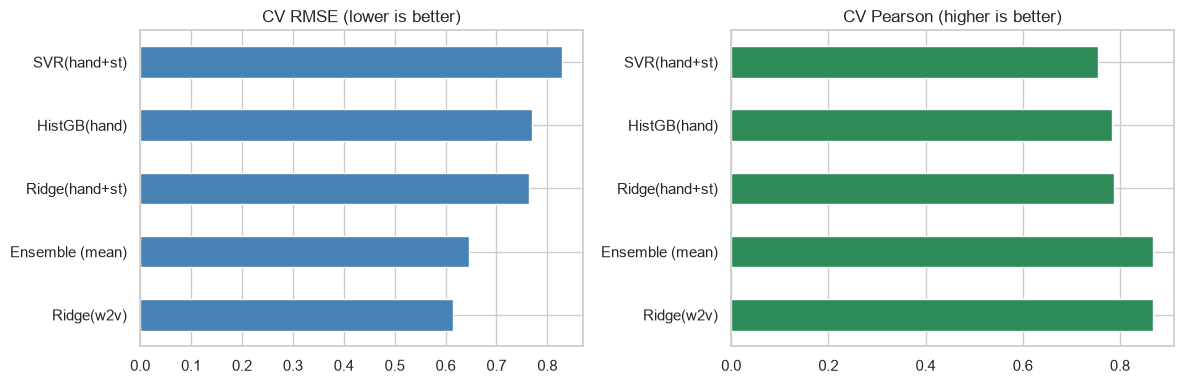

In [19]:
# Visual comparison of the cross-validated models
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cv_results["RMSE"].plot.barh(ax=ax[0], color="steelblue"); ax[0].set_title("CV RMSE (lower is better)")
cv_results["Pearson"].plot.barh(ax=ax[1], color="seagreen"); ax[1].set_title("CV Pearson (higher is better)")
plt.tight_layout(); plt.show()

## 6. Final training, **training-set RMSE**, and diagnostics
Every model is refit on the full training set. `Train RMSE` below is the compulsory score of the final pipeline on the training data;
the cross-validated (OOF) RMSE is reported next to it because it is the more realistic estimate of generalisation.

In [20]:
final_models, train_pred, test_pred = {}, {}, {}
for m, (names, make) in MODELS.items():
    Xtr, Xte = stack_blocks(X_blocks_train, names), stack_blocks(X_blocks_test, names)
    est = make().fit(Xtr, y)
    final_models[m] = est
    train_pred[m], test_pred[m] = est.predict(Xtr), est.predict(Xte)

train_ens = np.clip(np.mean(list(train_pred.values()), axis=0), 0, 5)
test_ens  = np.clip(np.mean(list(test_pred.values()),  axis=0), 0, 5)
oof_ens   = np.clip(oof["Ensemble (mean)"], 0, 5)

train_metrics = evaluate(y, train_ens)
cv_metrics    = evaluate(y, oof_ens)
print("=" * 55)
print(f"TRAIN RMSE (final ensemble, fit on all train): {train_metrics['RMSE']:.4f}")
print(f"TRAIN Pearson                                : {train_metrics['Pearson']:.4f}")
print(f"5-fold CV (OOF) RMSE                         : {cv_metrics['RMSE']:.4f}")
print(f"5-fold CV (OOF) Pearson                      : {cv_metrics['Pearson']:.4f}")
print("=" * 55)

TRAIN RMSE (final ensemble, fit on all train): 0.3635
TRAIN Pearson                                : 0.9657
5-fold CV (OOF) RMSE                         : 0.6464
5-fold CV (OOF) Pearson                      : 0.8672


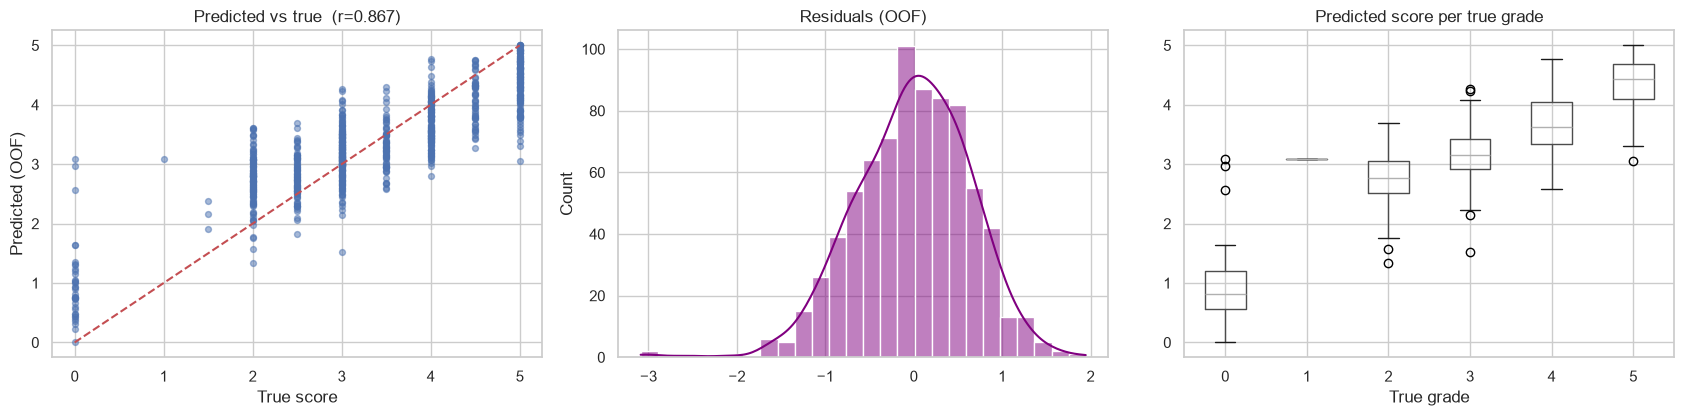

In [21]:
res = y - oof_ens
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

ax[0].scatter(y, oof_ens, alpha=0.5, s=18)
ax[0].plot([0, 5], [0, 5], "r--"); ax[0].set_xlabel("True score"); ax[0].set_ylabel("Predicted (OOF)")
ax[0].set_title(f"Predicted vs true  (r={cv_metrics['Pearson']:.3f})")

sns.histplot(res, kde=True, ax=ax[1], color="purple"); ax[1].set_title("Residuals (OOF)")

pd.DataFrame({"true": y.round().astype(int), "pred": oof_ens}).boxplot(by="true", column="pred", ax=ax[2])
ax[2].set_title("Predicted score per true grade"); ax[2].set_xlabel("True grade"); plt.suptitle("")
plt.tight_layout(); plt.show()

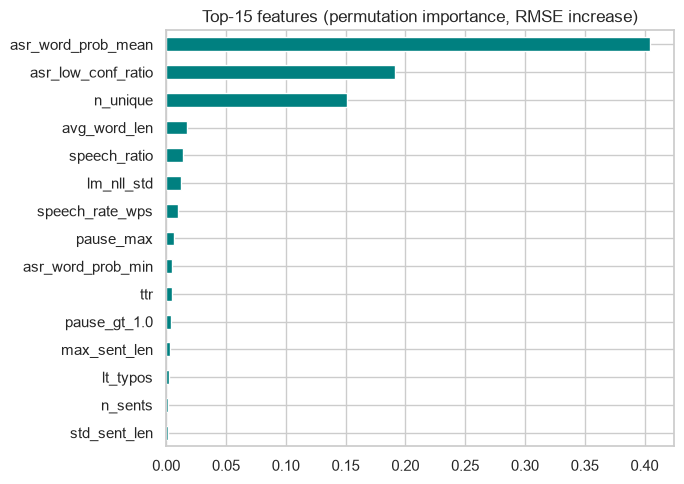

In [22]:
# Which handcrafted features matter most? (permutation importance on the gradient-boosting model, using OOF-style hold-out)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
Xh_tr, Xh_va, y_tr, y_va = train_test_split(HAND_train.values, y, test_size=0.25, random_state=SEED)
gb = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.04, max_iter=300, l2_regularization=1.0, random_state=SEED).fit(Xh_tr, y_tr)
pi = permutation_importance(gb, Xh_va, y_va, n_repeats=15, random_state=SEED, scoring="neg_root_mean_squared_error")
imp = pd.Series(pi.importances_mean, index=HAND_train.columns).sort_values().tail(15)
plt.figure(figsize=(7, 5)); imp.plot.barh(color="teal"); plt.title("Top-15 features (permutation importance, RMSE increase)")
plt.tight_layout(); plt.show()

## 7. Predict test set & create submission

In [40]:
print("test.csv col:", FILE_COL, "| sample_submission cols:", list(sub.columns))
print("test.csv  :", test[FILE_COL].head(3).tolist())
print("submission:", sub.iloc[:3, 0].tolist())
print("rows:", len(test), "vs", len(sub))

test.csv col: filename | sample_submission cols: ['filename', 'label']
test.csv  : ['audio_128.wav', 'audio_156.wav', 'audio_19.wav']
submission: ['audio_804.wav', 'audio_1028.wav', 'audio_865.wav']
rows: 216 vs 204


In [42]:
def norm(x): return Path(str(x).strip()).stem.lower()

t_names = set(test[FILE_COL].map(norm))
s_names = list(sub.iloc[:, 0].map(norm))
wavs    = {p.stem.lower(): p for p in DATA_DIR.rglob("*.wav")}

print("test.csv rows        :", len(test))
print("sample_submission    :", len(sub), "| columns:", list(sub.columns))
print("test.csv  examples   :", test[FILE_COL].head(3).tolist())
print("submission examples  :", sub.iloc[:3, 0].tolist())
print("overlap test vs sub  :", len(t_names & set(s_names)))
print("sub names that exist as .wav on disk:", sum(n in wavs for n in s_names))
print("test names that exist as .wav on disk:", sum(n in wavs for n in t_names))
print("all .wav files on disk:", len(wavs))
print("folders:", sorted({p.parent.name for p in DATA_DIR.rglob('*.wav')}))

test.csv rows        : 216
sample_submission    : 204 | columns: ['filename', 'label']
test.csv  examples   : ['audio_128.wav', 'audio_156.wav', 'audio_19.wav']
submission examples  : ['audio_804.wav', 'audio_1028.wav', 'audio_865.wav']
overlap test vs sub  : 25
sub names that exist as .wav on disk: 105
test names that exist as .wav on disk: 216
all .wav files on disk: 773
folders: ['test', 'train']


In [44]:
# 1) Every CSV the folder contains (there may be several versions)
for p in sorted(DATA_DIR.rglob("*.csv")):
    d = pd.read_csv(p)
    print(f"{p.relative_to(DATA_DIR)} | shape={d.shape} | cols={list(d.columns)}")
    print("   first names:", d.iloc[:3, 0].tolist())

# 2) Which CSV files the notebook is actually using
print("\nUsing:", TRAIN_CSV.relative_to(DATA_DIR), "|", TEST_CSV.relative_to(DATA_DIR), "|", SAMPLE_SUB.relative_to(DATA_DIR))

# 3) What the audio folders hold
from collections import Counter
print("\n.wav per folder:", Counter(p.parent.name for p in DATA_DIR.rglob("*.wav")))
print("example wav names:", [p.name for p in list(DATA_DIR.rglob("*.wav"))[:3]])

# 4) Matching against disk
wav_stems = {p.stem.lower() for p in DATA_DIR.rglob("*.wav")}
for name, names in [("train", train[FILE_COL]), ("test", test[FILE_COL]), ("sample_sub", sub.iloc[:, 0])]:
    n = [Path(str(x).strip()).stem.lower() for x in names]
    print(f"{name:10s}: {sum(s in wav_stems for s in n)} of {len(n)} found on disk")

sample_submission.csv | shape=(204, 2) | cols=['filename', 'label']
   first names: ['audio_804.wav', 'audio_1028.wav', 'audio_865.wav']
test.csv | shape=(216, 2) | cols=['filename', 'label']
   first names: ['audio_128.wav', 'audio_156.wav', 'audio_19.wav']
train.csv | shape=(769, 2) | cols=['filename', 'label']
   first names: ['audio_192.wav', 'audio_436.wav', 'audio_447.wav']

Using: train.csv | test.csv | sample_submission.csv

.wav per folder: Counter({'train': 769, 'test': 216})
example wav names: ['audio_0.wav', 'audio_1.wav', 'audio_10.wav']
train     : 769 of 769 found on disk
test      : 216 of 216 found on disk
sample_sub: 105 of 204 found on disk


(216, 2)


,filename,label
0,audio_128.wav,2.571215
1,audio_156.wav,3.407815
2,audio_19.wav,3.303241
3,audio_108.wav,2.320575
4,audio_206.wav,4.615493


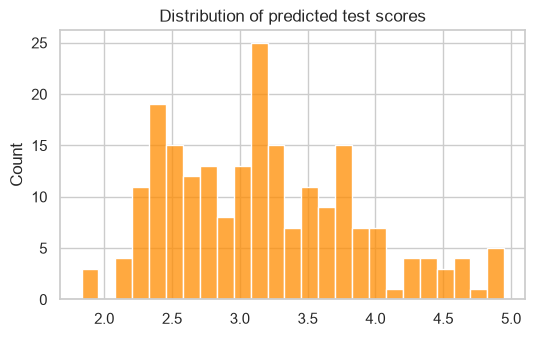

In [23]:
# Build the submission from test.csv (216 real test clips), using the same columns as sample_submission.csv
submission = pd.DataFrame({
    sub.columns[0]: test[FILE_COL].values,   # 'filename'
    sub.columns[1]: test_ens                 # 'label' = predicted grammar score (0-5)
})

assert len(submission) == 216 and submission["label"].notna().all()
assert submission["label"].between(0, 5).all()

submission.to_csv("submission1.csv", index=False)
print(submission.shape); display(submission.head())

plt.figure(figsize=(6, 3.5)); sns.histplot(test_ens, bins=25, color="darkorange")
plt.title("Distribution of predicted test scores"); plt.show()

## 8. Report

### 8.1 Problem & approach
Predict the grammar proficiency (continuous 0-5) of a 45-60 s spoken sample. Because the rubric judges sentence structure, syntax and
error frequency, the pipeline is **transcript-centric**: speech is transcribed and then analysed linguistically, while acoustic features
capture fluency cues (pauses, hesitations) that human raters also react to.

### 8.2 Preprocessing
* Audio loaded as mono, 16 kHz (required by Whisper/wav2vec2); clips capped at 60 s.
* Whisper `small.en` transcription with word timestamps and confidences; results cached.
* Missing/degenerate transcripts handled with safe defaults; predictions clipped to [0, 5].

### 8.3 Pipeline architecture
```
audio ──► Whisper ASR ──► transcript ──┬─► GPT-2 NLL + LanguageTool + sentence/filler/repetition stats ─┐
   │                 └─► word timings ─┴─► pause / speech-rate / ASR-confidence features               ├─► [hand]
   │                                    └─► MiniLM sentence embedding ───────────────────────────────── ► [st]
   └──► wav2vec2-base (layer 6 mean+std, last-layer mean) ───────────────────────────────────────────── ► [w2v]

[hand]+[st] ► Ridge     [w2v] ► Ridge     [hand]+[st] ► SVR     [hand] ► HistGradientBoosting
                         └────────────────  mean ensemble  ► clip(0,5) ► score
```

### 8.4 Evaluation
Metrics: **RMSE** (error magnitude) and **Pearson correlation** (ranking quality, used on the leaderboard).
Results are printed in Section 6: *train RMSE* of the final ensemble (required) and 5-fold OOF RMSE / Pearson (honest generalisation estimate).
Expect train RMSE < CV RMSE; a large gap would indicate over-fitting, mitigated here by strong regularisation (Ridge, shallow trees, small SVR C)
and by averaging diverse models.

### 8.5 Interpretation
* Features such as LanguageTool errors per 100 words, GPT-2 negative log-likelihood, sentence length, filler/repeat rates and pause counts show the
  expected relationships with grammar score (see correlation and permutation-importance plots).
* Residual plots reveal regression-to-the-mean: extreme grades (very low / very high) are predicted closer to the average, typical for MOS-style labels with few samples.

### 8.6 Limitations & next steps
* Whisper normalises/“repairs” ungrammatical speech, so some errors are hidden; a verbatim-style ASR or a CTC model would keep disfluencies.
* Only 769 training clips: fine-tuning a transformer end-to-end is risky; a next step is to fine-tune a small text encoder (DeBERTa) on the transcripts
  with CV, and to add it to the ensemble.
* Tune the ensemble weights (e.g. non-negative stacking) and try `whisper-medium` for better transcripts.